# 03 · Product Affinity và Recommendation — Santander

Bản v1: popularity, association rules đơn sản phẩm và temporal affinity. Điểm là **ranking score**, không phải xác suất cá nhân. Không train CLV. Item2vec và mô hình xác suất là bước sau, chưa triển khai.

Notebook chưa chạy trên dữ liệu thật trong phiên làm việc này. Các hàm lõi được kiểm thử bằng dữ liệu giả lập. Chạy lần lượt trên Kaggle với dữ liệu raw và output RFM/lifecycle của bạn.

**Đơn vị:** khách–tháng; 24 sản phẩm. Nhãn: mọi chuyển 0→1 giữa hai tháng liên tiếp, gồm mở lại. Không coi thiếu snapshot là nhãn 0. Mỗi tháng fit dùng một snapshot để tránh khách có lịch sử dài được đếm nhiều lần trong ma trận đồng sở hữu.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path('/kaggle/working')
RAW_PATH = Path('/kaggle/input/competitions/santander-product-recommendation/train_ver2.csv.zip')
RFM_ROOT = ROOT  # Nếu mount output RFM: Path('/kaggle/input/<rfm-output>')
LIFECYCLE_ROOT = ROOT / 'lifecycle_eda'  # Hoặc thư mục output lifecycle đã mount
FEATURE_DIR = RFM_ROOT / 'customer_month_features'
RFM_LABEL_DIR = RFM_ROOT / 'rfm_labels'
THRESHOLD_PATH = RFM_ROOT / 'rfm_thresholds.json'
LIFECYCLE_DIR = LIFECYCLE_ROOT / 'customer_lifecycle'
CACHE = ROOT / 'affinity_snapshot_cache'
OUT = ROOT / 'affinity_outputs'
CACHE.mkdir(parents=True, exist_ok=True); OUT.mkdir(parents=True, exist_ok=True)
REQUIRE_RFM = True
REQUIRE_LIFECYCLE = True  # Output đầy đủ từ customer-lifecycle.ipynb cập nhật
SHOW_DETAILS = False
TOP_K = 7
MIN_PAIR_COUNT = 100
MIN_TEMP_EXPOSURE = 1000
GROUP_PRIOR = 1000.0
# Chọn phương pháp trên 12/2015; khóa trước khi xem test 01–04/2016.
VALID_MONTH = '2015-12'
TEST_MONTHS = ['2016-01', '2016-02', '2016-03', '2016-04']
RECOMMEND_MONTH = '2016-05'  # Không có nhãn 06/2016 trong train
BATCH_SIZE = 25000
WRITE_ALL_TEST_RECOMMENDATIONS = False
PRODUCTS = ['ind_ahor_fin_ult1','ind_aval_fin_ult1','ind_cco_fin_ult1','ind_cder_fin_ult1',
'ind_cno_fin_ult1','ind_ctju_fin_ult1','ind_ctma_fin_ult1','ind_ctop_fin_ult1',
'ind_ctpp_fin_ult1','ind_deco_fin_ult1','ind_deme_fin_ult1','ind_dela_fin_ult1',
'ind_ecue_fin_ult1','ind_fond_fin_ult1','ind_hip_fin_ult1','ind_plan_fin_ult1',
'ind_pres_fin_ult1','ind_reca_fin_ult1','ind_tjcr_fin_ult1','ind_valo_fin_ult1',
'ind_viv_fin_ult1','ind_nomina_ult1','ind_nom_pens_ult1','ind_recibo_ult1']
assert len(PRODUCTS) == 24

def next_month(m): return str(pd.Period(m, 'M') + 1)
def prev_month(m): return str(pd.Period(m, 'M') - 1)
def snapshot(m): return pd.read_parquet(CACHE / f'{m}.parquet')

PRODUCT_MAP = {'ind_ahor_fin_ult1': 'prod_saving_account', 'ind_aval_fin_ult1': 'prod_guarantees', 'ind_cco_fin_ult1': 'prod_current_account', 'ind_cder_fin_ult1': 'prod_derivada_account', 'ind_cno_fin_ult1': 'prod_payroll_account', 'ind_ctju_fin_ult1': 'prod_junior_account', 'ind_ctma_fin_ult1': 'prod_mas_particular_account', 'ind_ctop_fin_ult1': 'prod_particular_account', 'ind_ctpp_fin_ult1': 'prod_particular_plus_account', 'ind_deco_fin_ult1': 'prod_short_term_deposit', 'ind_deme_fin_ult1': 'prod_medium_term_deposit', 'ind_dela_fin_ult1': 'prod_long_term_deposit', 'ind_ecue_fin_ult1': 'prod_eaccount', 'ind_fond_fin_ult1': 'prod_funds', 'ind_hip_fin_ult1': 'prod_mortgage', 'ind_plan_fin_ult1': 'prod_pension_plan', 'ind_pres_fin_ult1': 'prod_loans', 'ind_reca_fin_ult1': 'prod_taxes', 'ind_tjcr_fin_ult1': 'prod_credit_card', 'ind_valo_fin_ult1': 'prod_securities', 'ind_viv_fin_ult1': 'prod_home_account', 'ind_nomina_ult1': 'prod_payroll', 'ind_nom_pens_ult1': 'prod_pension_payroll', 'ind_recibo_ult1': 'prod_direct_debit'}


In [2]:
# Tự tìm output khi Kaggle mount notebook/dataset vào /kaggle/input.
# Chỉ chọn tự động khi duy nhất một bộ file đủ tháng; nhiều bộ thì yêu cầu chọn root.
def resolve_output_dir(configured, pattern, required_names, label):
    configured=Path(configured)
    if all((configured/name).exists() for name in required_names): return configured
    candidates=set()
    search_root=Path('/kaggle/input')
    if search_root.exists():
        candidates={p.parent for p in search_root.rglob(pattern)}
    valid=sorted([d for d in candidates if all((d/name).exists() for name in required_names)])
    if len(valid)==1:
        print(f'{label}: tìm thấy {valid[0]}');return valid[0]
    if len(valid)>1:
        raise ValueError(f'{label}: có nhiều bộ output. Chọn đường dẫn ở ô cấu hình: '+str(valid))
    detail='; '.join(f'{d} ({sum((d/name).exists() for name in required_names)}/{len(required_names)} tháng)' for d in sorted(candidates))
    raise FileNotFoundError(f'{label}: chưa tìm thấy output đủ tháng. '
        'Trong Kaggle, Add Input/Add Data để gắn output notebook đã Save Version (Run All). '
        'Upload file .ipynb không tự mang theo Parquet. Các thư mục tìm thấy: '+(detail or 'không có'))

required_months=[str(m) for m in pd.period_range('2015-01',RECOMMEND_MONTH,freq='M')]
FEATURE_DIR=resolve_output_dir(FEATURE_DIR,'customer_features_????-??.parquet',
    [f'customer_features_{m}.parquet' for m in required_months],'RFM features')
RFM_ROOT=FEATURE_DIR.parent
if not THRESHOLD_PATH.exists():THRESHOLD_PATH=RFM_ROOT/'rfm_thresholds.json'
if not RFM_LABEL_DIR.exists():RFM_LABEL_DIR=RFM_ROOT/'rfm_labels'
if REQUIRE_LIFECYCLE:
    LIFECYCLE_DIR=resolve_output_dir(LIFECYCLE_DIR,'customer_lifecycle_????-??.parquet',
        [f'customer_lifecycle_{m}.parquet' for m in required_months],'Lifecycle đầy đủ')
    LIFECYCLE_ROOT=LIFECYCLE_DIR.parent
print('RFM:',FEATURE_DIR,'\nLifecycle:',LIFECYCLE_DIR,'\nThresholds:',THRESHOLD_PATH)


RFM features: tìm thấy /kaggle/input/notebooks/thientrantdt/rfm-lifecycle/customer_month_features
Lifecycle đầy đủ: tìm thấy /kaggle/input/notebooks/thientrantdt/customer-lifecycle/lifecycle_eda/customer_lifecycle
RFM: /kaggle/input/notebooks/thientrantdt/rfm-lifecycle/customer_month_features 
Lifecycle: /kaggle/input/notebooks/thientrantdt/customer-lifecycle/lifecycle_eda/customer_lifecycle 
Thresholds: /kaggle/input/notebooks/thientrantdt/rfm-lifecycle/rfm_thresholds.json


In [3]:
# Kiểm tra contract trước khi đọc raw lớn
required_months=[str(m) for m in pd.period_range('2015-01',RECOMMEND_MONTH,freq='M')]
paths=[]
for m in required_months:
    for kind,path in [('rfm',FEATURE_DIR/f'customer_features_{m}.parquet'),
                      ('lifecycle',LIFECYCLE_DIR/f'customer_lifecycle_{m}.parquet')]:
        paths.append({'month':m,'kind':kind,'exists':path.exists(),'path':str(path)})
inventory=pd.DataFrame(paths)
display(inventory.groupby('kind').exists.agg(['sum','count']))
missing=inventory[~inventory.exists & ((inventory.kind=='rfm') | REQUIRE_LIFECYCLE)]
if len(missing): raise FileNotFoundError('Chạy notebook upstream hoặc sửa root:\n'+'\n'.join(missing.path))
assert THRESHOLD_PATH.exists(), THRESHOLD_PATH
if REQUIRE_LIFECYCLE:
    manifest_path=LIFECYCLE_DIR/'manifest.json'
    assert manifest_path.exists(), 'Thiếu manifest: chạy lifecycle cập nhật, không dùng history_sample'
    manifest=json.loads(manifest_path.read_text())
    assert manifest['scope']=='all known customers per month'


,sum,count
kind,,
lifecycle,17,17
rfm,17,17


## 0. Khách hàng cần dự đoán

Tháng chốt là RECOMMEND_MONTH; dự đoán acquisition tháng kế tiếp. Mặc định toàn bộ khách đã biết trong RFM panel tại tháng chốt được nhận gợi ý, kể cả khách vắng snapshot. Đây không phải danh sách riêng của test Kaggle. Không lọc bằng dữ liệu tương lai.

Bảng sau hiển thị từng khách và phân bố lifecycle/RFM; xuất toàn bộ danh sách thành prediction_customers_YYYY-MM.parquet. is_observed nghĩa là có record tại tháng chốt; chưa đảm bảo đủ 24 cờ. is_stale là dữ liệu mang từ snapshot trước. No_Acquisition_Event không đồng nghĩa inactive. RFM trước tháng fit được ghi Not_yet_fitted.


In [4]:
def build_prediction_customers(m):
    f=pd.read_parquet(FEATURE_DIR/f'customer_features_{m}.parquet')
    needed=['customer_id','as_of_month','is_observed','is_stale','months_since_last_seen',
            'R','F_event_months','M_n_products','has_event','observed_months','tenure_months']
    assert set(needed).issubset(f.columns)
    assert not f.customer_id.duplicated().any()
    assert pd.to_datetime(f.as_of_month).dt.strftime('%Y-%m').eq(m).all()
    target=f[needed].copy()
    lp=LIFECYCLE_DIR/f'customer_lifecycle_{m}.parquet'
    if lp.exists():
        life=pd.read_parquet(lp)
        assert not life.customer_id.duplicated().any()
        assert pd.to_datetime(life.as_of_month).dt.strftime('%Y-%m').eq(m).all()
        assert target.customer_id.isin(life.customer_id).all(), 'Lifecycle thiếu khách mục tiêu'
        cols=['customer_id','lifecycle']+[c for c in ['lifecycle_reason','is_observed'] if c in life]
        target=target.merge(life[cols],on='customer_id',validate='one_to_one',suffixes=('','_life'))
        if 'is_observed_life' in target:
            assert target.is_observed.eq(target.is_observed_life).all(), 'RFM và lifecycle không cùng phiên'
            target=target.drop(columns='is_observed_life')
    else:
        if REQUIRE_LIFECYCLE:raise FileNotFoundError(lp)
        target['lifecycle']='Missing'
    params=json.loads(THRESHOLD_PATH.read_text())
    fit_month=str(params['meta']['fit_month'])[:7]
    target['q_segment']='Not_yet_fitted'
    observed=target.is_observed.astype(bool)
    if m>=fit_month:
        q=params['configs']['FM_MNP']['quantile'];tiers=[]
        for col,cuts,invert in [('R',q['R_cuts'],True),('F_event_months',q['F_cuts'],False),
                               ('M_n_products',q['M_cuts'],False)]:
            v=pd.to_numeric(target[col],errors='coerce').to_numpy(dtype=float)
            ix=np.searchsorted(np.asarray(cuts,dtype=float),v,side='left')
            t=len(cuts)+1-ix if invert else ix+1
            tiers.append(pd.Series(np.where(np.isnan(v),np.nan,t),index=target.index).astype('Int64').astype('string').fillna('?'))
        target['q_segment']=np.where(target.has_event.fillna(False),'R'+tiers[0]+'F'+tiers[1]+'M'+tiers[2],'No_Acquisition_Event')
        # Notebook RFM gốc chỉ chấm khách có snapshot; không tự chấm dữ liệu cũ.
        target.loc[~observed,'q_segment']='Not_scored_stale'
        label_path=RFM_LABEL_DIR/f'rfm_labels_FM_MNP_{m}.parquet'
        if label_path.exists():
            lab=pd.read_parquet(label_path)
            assert not lab.customer_id.duplicated().any()
            assert pd.to_datetime(lab.as_of_month).dt.strftime('%Y-%m').eq(m).all()
            check=target.loc[observed,['customer_id','q_segment']].merge(lab[['customer_id','q_segment']],
                on='customer_id',how='left',validate='one_to_one',suffixes=('','_saved'))
            assert check.q_segment_saved.notna().all(), 'Nhãn RFM thiếu khách observed'
            assert check.q_segment.astype(str).eq(check.q_segment_saved.astype(str)).all(), 'Ngưỡng/nhãn RFM không khớp'
    target['prediction_month']=next_month(m)
    target['target_source']='RFM_panel_all_known_customers'
    return target.sort_values('customer_id').reset_index(drop=True)

prediction_customers=build_prediction_customers(RECOMMEND_MONTH)
counts=pd.DataFrame([{'as_of_month':RECOMMEND_MONTH,'prediction_month':next_month(RECOMMEND_MONTH),
    'n_target':len(prediction_customers),'n_observed':int(prediction_customers.is_observed.sum()),
    'n_stale':int(prediction_customers.is_stale.sum()),
    'n_no_acquisition_history':int((~prediction_customers.has_event).sum())}])
display(counts)
for col in ['lifecycle','q_segment']:
    view=prediction_customers.groupby(col,dropna=False,observed=True).size().rename('n_customers').reset_index()
    view['share']=view.n_customers/max(len(prediction_customers),1)
    display(view.sort_values('n_customers',ascending=False).reset_index(drop=True))
preview_cols=['customer_id','as_of_month','prediction_month','is_observed','is_stale',
              'months_since_last_seen','lifecycle','R','F_event_months','M_n_products','q_segment']
display(prediction_customers[preview_cols].head(20))
# Điền ID muốn xem kỹ, không làm đổi danh sách cần dự đoán.
INSPECT_CUSTOMER_IDS=[]
if INSPECT_CUSTOMER_IDS:
    display(prediction_customers.loc[prediction_customers.customer_id.isin(INSPECT_CUSTOMER_IDS)])
prediction_customers.to_parquet(OUT/f'prediction_customers_{RECOMMEND_MONTH}.parquet',index=False)
counts.to_csv(OUT/f'prediction_customer_summary_{RECOMMEND_MONTH}.csv',index=False)
print('Đã xuất toàn bộ danh sách:',OUT/f'prediction_customers_{RECOMMEND_MONTH}.parquet')


,as_of_month,prediction_month,n_target,n_observed,n_stale,n_no_acquisition_history
0,2016-05,2016-06,956645,931453,25192,754849


,lifecycle,n_customers,share
0,Inactive,521386,0.545015
1,Active,392211,0.409986
2,Churned,21933,0.022927
3,At-risk,12050,0.012596
4,New,9032,0.009441
5,Win-back,33,0.000034


,q_segment,n_customers,share
0,No_Acquisition_Event,732966,0.766184
1,R1F1M1,45284,0.047336
2,Not_scored_stale,25192,0.026334
3,R1F2M1,14131,0.014771
4,R1F1M2,11960,0.012502
5,R3F3M2,10649,0.011132
6,R3F3M3,9327,0.009750
7,R3F1M1,8436,0.008818
8,R2F1M1,8404,0.008785
9,R3F3M1,8257,0.008631


,customer_id,as_of_month,prediction_month,is_observed,is_stale,months_since_last_seen,lifecycle,R,F_event_months,M_n_products,q_segment
0,15889,2016-05-28,2016-06,True,False,0,Active,0.0,4,4.0,R3F3M2
1,15890,2016-05-28,2016-06,True,False,0,Active,NaN,0,8.0,No_Acquisition_Event
2,15891,2016-05-28,2016-06,False,True,9,Churned,NaN,0,0.0,Not_scored_stale
3,15892,2016-05-28,2016-06,True,False,0,Active,8.0,2,7.0,R1F2M3
4,15893,2016-05-28,2016-06,True,False,0,Active,NaN,0,1.0,No_Acquisition_Event
5,15894,2016-05-28,2016-06,True,False,0,Active,8.0,3,8.0,R1F3M3
6,15895,2016-05-28,2016-06,True,False,0,Active,NaN,0,7.0,No_Acquisition_Event
7,15896,2016-05-28,2016-06,True,False,0,Active,2.0,5,4.0,R2F3M2
8,15897,2016-05-28,2016-06,True,False,0,Active,3.0,3,10.0,R2F3M3
9,15898,2016-05-28,2016-06,True,False,0,Inactive,NaN,0,0.0,No_Acquisition_Event


Đã xuất toàn bộ danh sách: /kaggle/working/affinity_outputs/prediction_customers_2016-05.parquet


**Cách đọc:** số khách cần gợi ý được xác định trước khi đọc nhãn tương lai. Phần đánh giá phía sau chỉ giữ khách đủ hai snapshot và báo label coverage. Danh sách preview 20 dòng là mẫu hiển thị; file Parquet chứa toàn bộ khách. Khách stale dùng popularity fallback ở bước gợi ý cuối.


## 1. Đầu vào đã đối chiếu với notebook bạn gửi

Chạy `rfm(2).ipynb` trước, giữ `customer_month_features/`, `rfm_labels/`, `rfm_thresholds.json`. RFM có 16 cột và không chứa 24 cờ từng sản phẩm, vì thế vẫn cần raw Santander để dựng affinity/nhãn theo sản phẩm.

Chạy `customer-lifecycle.ipynb` cập nhật: output đầy đủ là `lifecycle_eda/customer_lifecycle/customer_lifecycle_YYYY-MM.parquet`. Bản cũ chỉ có CSV tổng hợp và history_sample, không đủ ghép toàn bộ khách. Không cần đổi tên output RFM hay tính lại ngưỡng.

Sửa RAW_PATH, RFM_ROOT, LIFECYCLE_ROOT ở ô cấu hình. Cùng phiên RFM phải được dùng để tạo lifecycle. Khóa tháng được kiểm tra theo YYYY-MM từ as_of_month vì dữ liệu dùng ngày 28. Thiếu file, sai tháng, thiếu cột hoặc thiếu khách sẽ dừng, không âm thầm dùng mẫu.

Chỉ snapshot đầy đủ 24 cờ được phân tích. Không coi missing label là negative. Nhãn q_segment đọc từ file nếu có; tháng chưa xuất được tính bằng ngưỡng frozen trong JSON, không fit lại. Trước tháng fit không gán nhãn RFM bằng ngưỡng tương lai.


In [5]:
def raw_csv_columns(header):
    """Accept raw Santander or the exact prod_* names from the RFM notebook."""
    names=[str(c).strip().lstrip('\ufeff') for c in header]
    assert len(set(names))==len(names), 'Trùng tên cột sau strip'
    source_by_name=dict(zip(names,header))
    if not {'ncodpers','fecha_dato'}.issubset(names):
        raise ValueError('RAW_PATH cần snapshot có ncodpers, fecha_dato. Header đầu: '+str(names[:12]))
    missing=[];rename={};use=[source_by_name['ncodpers'],source_by_name['fecha_dato']]
    rename.update({source_by_name[k]:k for k in ['ncodpers','fecha_dato']})
    for raw in PRODUCTS:
        source=raw if raw in source_by_name else PRODUCT_MAP[raw] if PRODUCT_MAP[raw] in source_by_name else None
        if source is None:missing.append(raw)
        else:
            use.append(source_by_name[source]);rename[source_by_name[source]]=raw
    if missing:
        raise ValueError(f'RAW_PATH={RAW_PATH}: thiếu {len(missing)}/24 cột sở hữu sản phẩm. '
          'Nếu đang dùng test_ver2.csv, đổi sang train_ver2.csv hoặc train_ver2.csv.zip. '
          'Nếu là file đã xử lý, cần đủ 24 cờ ind_* hoặc prod_* theo PRODUCT_MAP. '
          'Không dùng monthly RFM features thay raw. Header đầu: '+str(names[:12]))
    return use,rename

def build_cache(raw_path, chunksize=300000):
    audit = []
    # Chạy lại: xóa riêng cache YYYY-MM do notebook này tạo, tránh append trùng.
    parts = {}
    handle = zipfile.ZipFile(raw_path) if str(raw_path).endswith('.zip') else None
    if handle:
        members = [n for n in handle.namelist() if n.endswith('.csv')]
        assert len(members) == 1, members
        stream = handle.open(members[0])
    else: stream = raw_path
    try:
        header=pd.read_csv(stream,nrows=0).columns.tolist()
        usecols,rename=raw_csv_columns(header)
        if handle:
            stream.close();stream=handle.open(members[0])
        else:stream=raw_path
        print('Raw schema hợp lệ: 24 cờ sản phẩm; file:',raw_path)
        for i, chunk in enumerate(pd.read_csv(stream, usecols=usecols,
                                              chunksize=chunksize, low_memory=False)):
            chunk=chunk.rename(columns=rename)
            chunk['month'] = pd.to_datetime(chunk.fecha_dato, errors='raise').dt.strftime('%Y-%m')
            for m, d in chunk.groupby('month', sort=False):
                x = d[PRODUCTS].apply(pd.to_numeric, errors='coerce')
                valid = x.isin([0,1]).all(axis=1)
                audit.append({'month':m,'n_raw':len(d),'n_complete':int(valid.sum())})
                good = x.loc[valid].astype('uint8')
                good.insert(0,'customer_id', pd.to_numeric(d.loc[valid,'ncodpers'],errors='raise').astype('int64'))
                p = CACHE / f'part_{m}_{i}.parquet'; good.to_parquet(p,index=False)
                parts.setdefault(m,[]).append(p)
        for m, paths in sorted(parts.items()):
            d = pd.concat([pd.read_parquet(p) for p in paths],ignore_index=True)
            assert not d.customer_id.duplicated().any(), f'Duplicate customer–month: {m}'
            d.sort_values('customer_id').to_parquet(CACHE / f'{m}.parquet',index=False)
            for p in paths: p.unlink()
    finally:
        if handle: handle.close()
    a = pd.DataFrame(audit).groupby('month',as_index=False)[['n_raw','n_complete']].sum()
    a['complete_coverage'] = a.n_complete / a.n_raw
    a.to_csv(OUT/'snapshot_coverage.csv',index=False)
    return a

coverage = build_cache(RAW_PATH)
display(coverage)


Raw schema hợp lệ: 24 cờ sản phẩm; file: /kaggle/input/competitions/santander-product-recommendation/train_ver2.csv.zip


,month,n_raw,n_complete,complete_coverage
0,2015-01,625457,622346,0.995026
1,2015-02,627394,624546,0.995461
2,2015-03,629209,626469,0.995645
3,2015-04,630367,627634,0.995664
4,2015-05,631957,629152,0.995561
5,2015-06,632110,630284,0.997111
6,2015-07,829817,829817,1.000000
7,2015-08,843201,843201,1.000000
8,2015-09,865440,865440,1.000000
9,2015-10,892251,892251,1.000000


**Cách đọc:** complete_coverage là tỷ lệ snapshot đủ 24 cờ để phân tích. Khách bị lọc chưa được coi là không sở hữu sản phẩm. Cache chỉ cần dựng lại khi thay raw; có thể thay ô trên bằng đọc snapshot_coverage.csv khi chạy lại.

In [6]:
def join_optional(m, base):
    d = base.copy()
    specs = [(FEATURE_DIR/f'customer_features_{m}.parquet', REQUIRE_RFM,
              ['R','F_event_months','M_n_products','has_event','is_observed','is_stale','observed_months','tenure_months']),
             (RFM_LABEL_DIR/f'rfm_labels_FM_MNP_{m}.parquet', REQUIRE_RFM, ['q_segment']),
             (LIFECYCLE_DIR/f'customer_lifecycle_{m}.parquet', REQUIRE_LIFECYCLE, ['lifecycle'])]
    for path, required, cols in specs:
        if not path.exists():
            if required and path.parent != RFM_LABEL_DIR: raise FileNotFoundError(path)
            continue
        f = pd.read_parquet(path)
        assert not f.customer_id.duplicated().any(), path
        if 'as_of_month' in f:
            assert pd.to_datetime(f.as_of_month).dt.strftime('%Y-%m').eq(m).all(), path
        required_cols=['customer_id','as_of_month'] + (['lifecycle'] if path.parent==LIFECYCLE_DIR else ['q_segment'] if path.parent==RFM_LABEL_DIR else cols)
        assert set(required_cols).issubset(f.columns), f'{path}: missing {set(required_cols)-set(f.columns)}'
        if required:
            assert d.customer_id.isin(f.customer_id).all(), f'{path}: thiếu khách trong input; không dùng preview'
        keep = ['customer_id']+[c for c in cols if c in f]
        d = d.merge(f[keep],on='customer_id',how='left',validate='one_to_one')
    # Notebook RFM chỉ xuất nhãn tại một số tháng: áp ngưỡng frozen cho tháng còn thiếu.
    if 'q_segment' not in d and THRESHOLD_PATH.exists() and m >= str(json.loads(THRESHOLD_PATH.read_text())['meta']['fit_month'])[:7]:
        threshold_path=THRESHOLD_PATH
        if not threshold_path.exists():
            if REQUIRE_RFM: raise FileNotFoundError(threshold_path)
        else:
            params=json.loads(threshold_path.read_text())
            fit_month=str(params['meta']['fit_month'])[:7]
            assert fit_month <= m, 'Không áp ngưỡng fit trong tương lai'
            p=params['configs']['FM_MNP']['quantile']
            tiers=[]
            for col,cuts,invert in [('R',p['R_cuts'],True),('F_event_months',p['F_cuts'],False),
                                    ('M_n_products',p['M_cuts'],False)]:
                v=pd.to_numeric(d[col],errors='coerce').to_numpy()
                ix=np.searchsorted(np.asarray(cuts,dtype=float),v,side='left')
                tier=len(cuts)+1-ix if invert else ix+1
                tiers.append(pd.Series(np.where(np.isnan(v),np.nan,tier),index=d.index).astype('Int64').astype('string').fillna('?'))
            has=d.has_event.fillna(False).astype(bool)
            d['q_segment']=np.where(has,'R'+tiers[0]+'F'+tiers[1]+'M'+tiers[2],'No_Acquisition_Event')
    for c in ['q_segment','lifecycle']:
        if c not in d: d[c] = 'Missing'
        d[c] = d[c].astype('string').fillna('Missing')
    if 'is_observed' in d:
        assert d.is_observed.fillna(False).all(), 'Raw và RFM không khớp quan sát'
    if 'M_n_products' in d and all(p in d for p in PRODUCTS):
        ok = d.M_n_products.notna()
        assert np.array_equal(d.loc[ok,PRODUCTS].sum(axis=1).to_numpy(),d.loc[ok,'M_n_products'].to_numpy())
    return d

def pair(m):
    a,b = snapshot(m), snapshot(next_month(m))
    d = a.merge(b,on='customer_id',suffixes=('_t','_next'),validate='one_to_one')
    X = d[[p+'_t' for p in PRODUCTS]].to_numpy(dtype=np.float32)
    Z = d[[p+'_next' for p in PRODUCTS]].to_numpy(dtype=np.float32)
    Y = ((X==0)&(Z==1)).astype(np.float32)
    return d.customer_id.to_numpy(), X, Y, len(a)


## 2. Ma trận đồng sở hữu và temporal affinity
Support/confidence/lift dùng snapshot tháng chốt. Temporal affinity dùng các cặp lịch sử mà tháng nhãn ≤ tháng chốt: P(mở B tháng sau | có A, chưa có B). Khách xuất hiện nhiều kỳ được đếm theo khách–tháng, không phải khách duy nhất. Temporal confidence là tỷ lệ nhóm, chưa phải xác suất cá nhân.

Popularity dùng acquisition rate trên khách chưa sở hữu từng sản phẩm (khác tỷ lệ sở hữu). Các nhóm lifecycle/RFM dùng tỷ lệ mở sản phẩm có smoothing về tỷ lệ chung; không fit một ma trận cho từng tổ hợp nhóm.

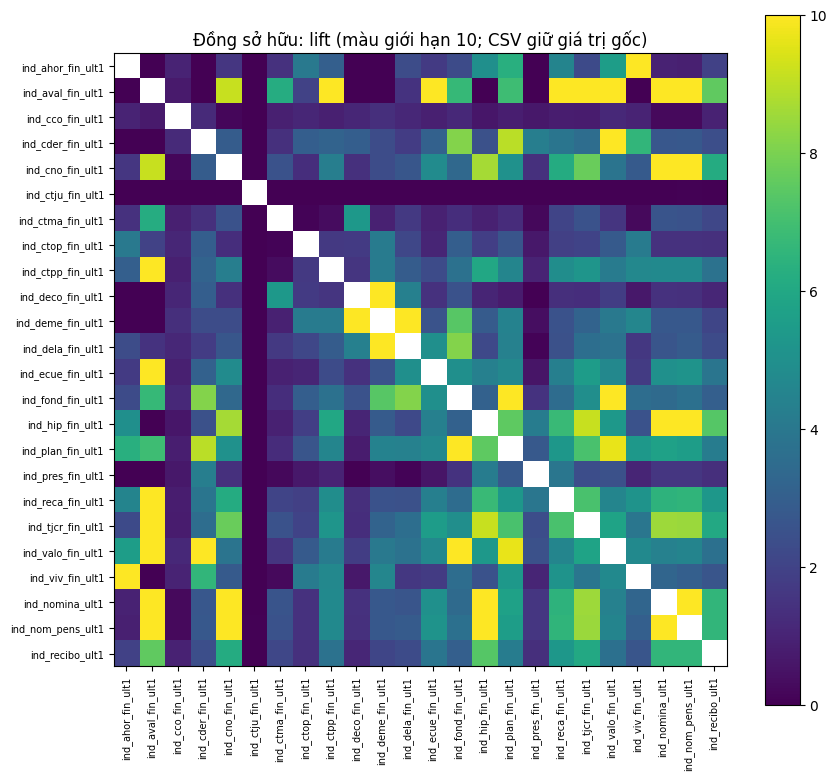

,A,B,n_pair,lift
273,ind_nomina_ult1,ind_nom_pens_ult1,47686.0,17.523027
102,ind_cno_fin_ult1,ind_nomina_ult1,44735.0,12.915802
103,ind_cno_fin_ult1,ind_nom_pens_ult1,48787.0,12.905454
222,ind_fond_fin_ult1,ind_plan_fin_ult1,1445.0,11.888868
185,ind_deme_fin_ult1,ind_dela_fin_ult1,537.0,11.285181
237,ind_hip_fin_ult1,ind_nomina_ult1,2626.0,10.840426
238,ind_hip_fin_ult1,ind_nom_pens_ult1,2704.0,10.227124
226,ind_fond_fin_ult1,ind_valo_fin_ult1,3518.0,10.209628
243,ind_plan_fin_ult1,ind_valo_fin_ult1,1617.0,9.652634
234,ind_hip_fin_ult1,ind_tjcr_fin_ult1,1682.0,9.149892


In [7]:
def coownership(X, min_count=MIN_PAIR_COUNT):
    n=len(X); counts=X.T@X; owners=X.sum(axis=0)
    support=counts/max(n,1)
    confidence=np.divide(counts, owners[:,None],out=np.zeros_like(counts),where=owners[:,None]>0)
    prevalence=owners/max(n,1)
    lift=np.divide(confidence,prevalence[None,:],out=np.zeros_like(counts),where=prevalence[None,:]>0)
    score=np.where(counts>=min_count,confidence*np.log1p(lift),0)
    np.fill_diagonal(score,0)
    return dict(count=counts,support=support,confidence=confidence,lift=lift,score=score)

def fit_at(cutoff):
    months=sorted(p.stem for p in CACHE.glob('????-??.parquet') if p.stem<cutoff)
    success=np.zeros(24); exposure=np.zeros(24)
    ts=np.zeros((24,24)); te=np.zeros((24,24)); groups={}
    audits=[]
    for m in months:
        # No label after cutoff: pair m -> m+1 only
        if next_month(m)>cutoff: continue
        ids,X,Y,n_origin=pair(m)
        success+=Y.sum(0); exposure+=(1-X).sum(0)
        ts+=X.T@Y; te+=X.T@(1-X)
        meta=join_optional(m,pd.DataFrame({'customer_id':ids}))
        for col in ['lifecycle','q_segment']:
            for label, ix in meta.groupby(col).indices.items():
                if label=='Missing': continue
                key=(col,str(label))
                if key not in groups: groups[key]=[np.zeros(24),np.zeros(24)]
                groups[key][0]+=Y[ix].sum(0);groups[key][1]+=(1-X[ix]).sum(0)
        audits.append({'origin_month':m,'label_month':next_month(m),'n_origin_complete':n_origin,
                       'n_paired':len(ids),'label_coverage':len(ids)/max(n_origin,1)})
    assert audits, 'Không có cặp train'
    pop=np.divide(success,exposure,out=np.zeros(24),where=exposure>0)
    temporal=np.divide(ts+GROUP_PRIOR*pop[None,:],te+GROUP_PRIOR)
    temporal[te<MIN_TEMP_EXPOSURE]=0
    np.fill_diagonal(temporal,0)
    rates={k:(s+GROUP_PRIOR*pop)/(e+GROUP_PRIOR) for k,(s,e) in groups.items()}
    co=coownership(snapshot(cutoff)[PRODUCTS].to_numpy(dtype=np.float32))
    return dict(cutoff=cutoff,pop=pop,co=co,temporal=temporal,temporal_success=ts,
                temporal_exposure=te,groups=rates,audit=pd.DataFrame(audits))

def export_model(model):
    folder=OUT/model['cutoff'];folder.mkdir(exist_ok=True)
    for k,v in model['co'].items():
        pd.DataFrame(v,index=PRODUCTS,columns=PRODUCTS).to_csv(folder/f'coownership_{k}.csv')
    for k in ['temporal','temporal_success','temporal_exposure']:
        pd.DataFrame(model[k],index=PRODUCTS,columns=PRODUCTS).to_csv(folder/f'{k}.csv')
    model['audit'].to_csv(folder/'training_coverage.csv',index=False)
    pd.DataFrame({'product':PRODUCTS,'acquisition_rate':model['pop']}).to_csv(folder/'popularity.csv',index=False)
    return folder

validation_model=fit_at(VALID_MONTH)
export_model(validation_model)
mat=validation_model['co']['lift'].copy();np.fill_diagonal(mat,np.nan)
fig,ax=plt.subplots(figsize=(9,8));im=ax.imshow(np.clip(mat,0,10),cmap='viridis')
ax.set_xticks(range(24),PRODUCTS,rotation=90,fontsize=7);ax.set_yticks(range(24),PRODUCTS,fontsize=7)
ax.set_title('Đồng sở hữu: lift (màu giới hạn 10; CSV giữ giá trị gốc)');fig.colorbar(im,ax=ax);plt.tight_layout();plt.show()
idx=np.triu_indices(24,1)
rules=pd.DataFrame({'A':np.array(PRODUCTS)[idx[0]],'B':np.array(PRODUCTS)[idx[1]],
                    'n_pair':validation_model['co']['count'][idx],'lift':mat[idx]})
display(rules.query('n_pair >= @MIN_PAIR_COUNT').sort_values('lift',ascending=False).head(12))


**Nhận xét cần viết sau chạy:** cặp nào có lift cao và đủ mẫu? Sản phẩm phổ biến nào có confidence cao nhưng lift gần 1? Đối chiếu temporal affinity trước khi kết luận một cặp phù hợp cross-sell. Đường chéo không dùng để gợi ý.

In [8]:
METHODS=['popularity','association','temporal','temporal_lifecycle','temporal_rfm','temporal_both']
def score_batch(model,X,meta,method):
    pop=np.broadcast_to(model['pop'],X.shape).copy()
    if method=='popularity': score=pop
    elif method=='association':
        raw=X@model['co']['score']
        score=raw+0.05*pop  # fixed ranking heuristic, not probability
    else:
        assert method in METHODS
        raw=X@model['temporal']/np.maximum(X.sum(1,keepdims=True),1)
        score=0.5*raw+0.5*pop
        cols={'temporal_lifecycle':['lifecycle'],'temporal_rfm':['q_segment'],
              'temporal_both':['lifecycle','q_segment']}.get(method,[])
        components=[]
        for col in cols:
            g=pop.copy()
            for label,ix in meta.groupby(col).indices.items():
                rate=model['groups'].get((col,str(label)))
                if rate is not None:g[ix]=rate
            components.append(g)
        if components: score=0.5*score+0.5*np.mean(components,axis=0)
    score[X==1]=-np.inf
    return score

def rank_scores(score,k=TOP_K):
    order=np.argsort(-score,axis=1,kind='stable')[:,:k]
    values=np.take_along_axis(score,order,axis=1)
    return np.where(np.isfinite(values),order,-1),values

def per_customer_metrics(Y,ranks):
    safe=np.maximum(ranks,0)
    hits=np.take_along_axis(Y,safe,axis=1)*(ranks>=0)
    n_true=Y.sum(1)
    precision=np.cumsum(hits,axis=1)/np.arange(1,ranks.shape[1]+1)
    ap=(precision*hits).sum(1)/np.maximum(np.minimum(n_true,ranks.shape[1]),1)
    recall=hits.sum(1)/np.maximum(n_true,1)
    return ap,recall,n_true

def evaluate(m,model,methods):
    assert model['cutoff']==m
    ids,X,Y,n_origin=pair(m)
    meta=join_optional(m,pd.DataFrame({'customer_id':ids}))
    summaries=[];by_group=[]
    for method in methods:
        ap_parts=[];rec_parts=[];true_parts=[];length_parts=[];items=set()
        for start in range(0,len(ids),BATCH_SIZE):
            sl=slice(start,start+BATCH_SIZE)
            ranks,values=rank_scores(score_batch(model,X[sl],meta.iloc[sl].reset_index(drop=True),method))
            ap,rec,nt=per_customer_metrics(Y[sl],ranks)
            ap_parts.append(ap);rec_parts.append(rec);true_parts.append(nt);length_parts.append((ranks>=0).sum(1))
            items.update(ranks[ranks>=0].tolist())
            if WRITE_ALL_TEST_RECOMMENDATIONS:write_recs(m,method,ids[sl],ranks,values,start)
        ap=np.concatenate(ap_parts);rec=np.concatenate(rec_parts);nt=np.concatenate(true_parts);length=np.concatenate(length_parts)
        pos=nt>0
        summaries.append(dict(month=m,method=method,n_evaluated=len(ids),label_coverage=len(ids)/max(n_origin,1),
                              acquisition_prevalence=float(pos.mean()),MAP7_all=float(ap.mean()),
                              MAP7_acquirers=float(ap[pos].mean()) if pos.any() else np.nan,
                              recall7_acquirers=float(rec[pos].mean()) if pos.any() else np.nan,
                              full7_coverage=float((length==TOP_K).mean()),item_coverage=len(items)/24))
        for col in ['lifecycle','q_segment']:
            for label,ix in meta.groupby(col).indices.items():
                by_group.append(dict(month=m,method=method,group_type=col,group=str(label),n=len(ix),
                                     MAP7_all=float(ap[ix].mean()),acquisition_prevalence=float(pos[ix].mean())))
    return pd.DataFrame(summaries),pd.DataFrame(by_group)

def write_recs(m,method,ids,ranks,values,part):
    lists=[[PRODUCTS[j] for j in row if j>=0] for row in ranks]
    scores=[[float(v) for j,v in zip(row,vals) if j>=0] for row,vals in zip(ranks,values)]
    folder=OUT/'product_recommendation'/m/method;folder.mkdir(parents=True,exist_ok=True)
    pd.DataFrame({'customer_id':ids,'as_of_month':m,'method':method,'products':lists,
                  'ranking_scores':scores}).to_parquet(folder/f'part_{part:07d}.parquet',index=False)


## 3. Validation và khóa lựa chọn trước test
MAP7_all gồm khách không acquisition (AP=0); MAP7_acquirers là chỉ số bổ sung, không thay thế mẫu số chính. Full7 coverage là tỷ lệ khách có đủ 7 ứng viên; item coverage là số sản phẩm xuất hiện trong gợi ý / 24. Label coverage là tỷ lệ khách snapshot đầy đủ tại t có snapshot đầy đủ tại t+1; không đại diện cho mọi khách mất quan sát.

Cách scoring và smoothing đã cố định trong cấu hình. Nếu chỉnh chúng sau validation, phải khóa lại trước test. Không chọn mô hình theo test.

In [9]:
available=['popularity','association','temporal']
if any(k[0]=='lifecycle' for k in validation_model['groups']):available.append('temporal_lifecycle')
if any(k[0]=='q_segment' for k in validation_model['groups']):available.append('temporal_rfm')
if {'temporal_lifecycle','temporal_rfm'}.issubset(available):available.append('temporal_both')
val,val_groups=evaluate(VALID_MONTH,validation_model,available)
val.to_csv(OUT/'validation_metrics.csv',index=False);val_groups.to_csv(OUT/'validation_groups.csv',index=False)
display(val.sort_values('MAP7_all',ascending=False))
# Baseline được ưu tiên khi chênh lệch nhỏ: chỉ chọn phức tạp hơn nếu > 0.0001 tuyệt đối.
best=val.sort_values('MAP7_all',ascending=False).iloc[0]
base=val.loc[val.method=='popularity','MAP7_all'].iloc[0]
SELECTED_METHOD=best['method'] if best.MAP7_all>base+0.0001 else 'popularity'
(OUT/'selection.json').write_text(json.dumps({'validation_month':VALID_MONTH,'selected_method':SELECTED_METHOD,
    'available_methods':available,'min_absolute_gain':0.0001,'not_probability':True},indent=2))
print('Khóa phương pháp:',SELECTED_METHOD)


,month,method,n_evaluated,label_coverage,acquisition_prevalence,MAP7_all,MAP7_acquirers,recall7_acquirers,full7_coverage,item_coverage
5,2015-12,temporal_both,908930,0.996611,0.0289,0.021213,0.734022,0.948426,1.0,0.916667
4,2015-12,temporal_rfm,908930,0.996611,0.0289,0.021127,0.731035,0.940056,1.0,0.916667
2,2015-12,temporal,908930,0.996611,0.0289,0.021115,0.730637,0.940433,1.0,0.833333
3,2015-12,temporal_lifecycle,908930,0.996611,0.0289,0.020627,0.713732,0.951342,1.0,0.833333
0,2015-12,popularity,908930,0.996611,0.0289,0.018780,0.649846,0.933958,1.0,0.833333
1,2015-12,association,908930,0.996611,0.0289,0.017245,0.596700,0.902073,1.0,0.875000


Khóa phương pháp: temporal_both


**Cách nhận xét:** so association với popularity, temporal với association, rồi temporal_lifecycle/rfm/both với temporal. Nếu lifecycle/RFM không tăng điểm thì vẫn giữ để giải thích nhóm, chưa đưa vào scoring chính. Một tháng validation chưa đủ chứng minh phương pháp luôn tốt.

Đã đánh giá 2016-01
Đã đánh giá 2016-02
Đã đánh giá 2016-03
Đã đánh giá 2016-04


,MAP7_all,MAP7_acquirers,full7_coverage,item_coverage
method,,,,
association,0.02070,0.64038,1.0,0.86458
popularity,0.02084,0.64926,1.0,0.83333
temporal,0.02453,0.75999,1.0,0.84375
temporal_both,0.02446,0.75967,1.0,0.91667
temporal_lifecycle,0.02368,0.73550,1.0,0.84375
temporal_rfm,0.02423,0.75300,1.0,0.92708


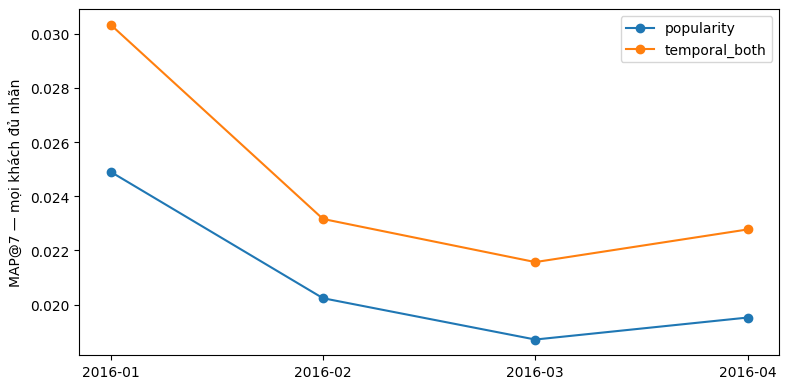

In [10]:
test=[];test_groups=[]
for m in TEST_MONTHS:
    model=fit_at(m)  # expanding-window: nhãn train cuối cùng ở tháng m, test ở m+1
    a,b=evaluate(m,model,available)
    test.append(a);test_groups.append(b)
    print('Đã đánh giá',m)
metrics=pd.concat(test,ignore_index=True);groups=pd.concat(test_groups,ignore_index=True)
metrics.to_csv(OUT/'test_metrics.csv',index=False);groups.to_csv(OUT/'test_groups.csv',index=False)
summary=metrics.groupby('method')[['MAP7_all','MAP7_acquirers','full7_coverage','item_coverage']].mean()
display(summary.round(5))
fig,ax=plt.subplots(figsize=(8,4))
for method in ['popularity',SELECTED_METHOD]:
    if method=='popularity' and SELECTED_METHOD=='popularity' and len(ax.lines):continue
    d=metrics[metrics.method==method];ax.plot(d.month,d.MAP7_all,marker='o',label=method)
ax.set_ylabel('MAP@7 — mọi khách đủ nhãn');ax.legend();plt.tight_layout();plt.show()
if SHOW_DETAILS:display(groups)


**Nhận xét sau test:** phương pháp đã khóa có thắng baseline qua các tháng không? Lợi ích có tập trung ở một nhóm lớn? Luôn đọc n và acquisition_prevalence trước khi so MAP giữa các nhóm. Báo cáo test trung thực kể cả giảm điểm; không đổi selection theo test. Mean theo tháng trong bảng khác pooled mean theo khách nếu các tháng có kích thước khác nhau.

## 4. Gợi ý tháng cuối cho toàn bộ khách RFM
Khách có snapshot đầy đủ: dùng danh mục hiện tại và loại sản phẩm đang sở hữu. Khách chỉ có danh mục cũ hoặc snapshot thiếu: dùng popularity và loại các sản phẩm **biết là đang sở hữu ở snapshot gần nhất**; đánh dấu catalog_status. Không khẳng định danh mục cũ là hiện tại. Các khách không có bằng chứng về một sản phẩm vẫn có thể nhận gợi ý đó. Việc gợi ý mọi khách không có nghĩa đánh giá được mọi khách.

RFM monthly panel phải phủ toàn bộ khách đã xuất hiện đến tháng chốt như notebook gốc. Nếu chỉ có mẫu/preview, không đáp ứng yêu cầu toàn bộ khách.

In [11]:
final_model=fit_at(RECOMMEND_MONTH);export_model(final_model)
current=snapshot(RECOMMEND_MONTH)
feature_path=FEATURE_DIR/f'customer_features_{RECOMMEND_MONTH}.parquet'
assert feature_path.exists(), 'Cần monthly RFM panel để recommend toàn bộ khách'
assert RECOMMEND_MONTH == prediction_customers.as_of_month.dt.strftime('%Y-%m').iloc[0]
universe=prediction_customers[['customer_id']].copy()
assert not universe.customer_id.duplicated().any()
last=pd.DataFrame(columns=PRODUCTS+['catalog_month'])
last.index.name='customer_id'
for p in sorted(CACHE.glob('????-??.parquet')):
    if p.stem>RECOMMEND_MONTH:continue
    frame=pd.read_parquet(p).set_index('customer_id')
    frame['catalog_month']=p.stem
    last=pd.concat([last.loc[~last.index.isin(frame.index)],frame])
for start in range(0,len(universe),BATCH_SIZE):
    ids=universe.customer_id.iloc[start:start+BATCH_SIZE].to_numpy()
    catalog=last.reindex(ids)
    X=catalog[PRODUCTS].fillna(0).to_numpy(dtype=np.float32)
    status=np.where(catalog.catalog_month.eq(RECOMMEND_MONTH),'current_complete',
                    np.where(catalog.catalog_month.notna(),'last_complete_snapshot','no_complete_snapshot')).tolist()
    # Chỉ check raw–RFM is_observed trên current; metadata all-customer không được assert observed.
    current_ids=set(current.customer_id)
    # Reuse validated join on observed complete rows; stale clients use popularity.
    observed=np.array([cid in current_ids for cid in ids])
    meta=pd.DataFrame({'customer_id':ids,'lifecycle':'Missing','q_segment':'Missing'})
    if observed.any():
        joined=join_optional(RECOMMEND_MONTH,pd.DataFrame({'customer_id':ids[observed]}))
        for col in ['lifecycle','q_segment']:meta.loc[observed,col]=joined[col].to_numpy()
    score=score_batch(final_model,X,meta,SELECTED_METHOD)
    stale=np.array(status)!='current_complete'
    score[stale]=score_batch(final_model,X[stale],meta.loc[stale].reset_index(drop=True),'popularity')
    ranks,values=rank_scores(score)
    write_recs(RECOMMEND_MONTH,SELECTED_METHOD,ids,ranks,values,start)
    pd.DataFrame({'customer_id':ids,'catalog_status':status,
                  'scoring_method':np.where(stale,'popularity_fallback',SELECTED_METHOD)}).to_parquet(
        OUT/'product_recommendation'/RECOMMEND_MONTH/SELECTED_METHOD/f'status_{start:07d}.parquet',index=False)
print('Đã xuất gợi ý cho',len(universe),'khách; catalog_status lưu riêng để kiểm tra')


/tmp/ipykernel_16/2186280510.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X=catalog[PRODUCTS].fillna(0).to_numpy(dtype=np.float32)
/tmp/ipykernel_16/2186280510.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X=catalog[PRODUCTS].fillna(0).to_numpy(dtype=np.float32)
/tmp/ipykernel_16/2186280510.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_dow

Đã xuất gợi ý cho 956645 khách; catalog_status lưu riêng để kiểm tra


## 5. Kết luận cần hoàn thiện sau chạy
- Phương pháp chọn trên validation và MAP test theo tháng.
- Lợi ích bổ sung của RFM/lifecycle, không giả định sẵn rằng chúng tốt hơn.
- Coverage snapshot, label, recommendation, catalog freshness.
- Các cặp sản phẩm có đủ support; temporal affinity có cùng chiều không.
- Hạn chế: snapshot tháng, missing observation, không có xác suất cá nhân đã calibrated; chưa thử item2vec.

Output chính ở affinity_outputs: ma trận CSV, audit coverage, metrics, selection.json và recommendations Parquet theo batch. Không có kết quả thật được điền sẵn.